In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
ddos_data = pd.read_csv('https://raw.githubusercontent.com/RayFarrington/MLTests/refs/heads/master/data/DDOS_Data.csv')
#https://www.kaggle.com/code/atulkumar011/ddos-attack-detection-classification-a03d6b
ddos_data.head()

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,1.010000e+11,3,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2.810000e+11,2,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0


# EDA

In [ ]:
ddos_data.info(show_counts=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104345 entries, 0 to 104344
Data columns (total 23 columns):
 #   Column       Dtype  
---  ------       -----  
 0   dt           int64  
 1   switch       int64  
 2   src          object 
 3   dst          object 
 4   pktcount     int64  
 5   bytecount    int64  
 6   dur          int64  
 7   dur_nsec     int64  
 8   tot_dur      float64
 9   flows        int64  
 10  packetins    int64  
 11  pktperflow   int64  
 12  byteperflow  int64  
 13  pktrate      int64  
 14  Pairflow     int64  
 15  Protocol     object 
 16  port_no      int64  
 17  tx_bytes     int64  
 18  rx_bytes     int64  
 19  tx_kbps      int64  
 20  rx_kbps      float64
 21  tot_kbps     float64
 22  label        int64  
dtypes: float64(3), int64(17), object(3)
memory usage: 18.3+ MB


In [ ]:
ddos_data.isnull().sum()

,0
dt,0
switch,0
src,0
dst,0
pktcount,0
bytecount,0
dur,0
dur_nsec,0
tot_dur,0
flows,0


In [ ]:
#Here I am testing the hypothosis that total kbps is null at the same time the rx kbps is null. This makes sense because total = tx + rx
rx_null = ddos_data[ddos_data['rx_kbps'].isnull()].index
tot_test = ddos_data.loc[rx_null, 'tot_kbps'].isnull()
#if this is true then tot_kbps is null when rx_kbps is null, which is important to keep in mind when I deal with the missing values
tot_test.all()

np.True_

In [ ]:
ddos_data.describe()

,dt,switch,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,pktperflow,byteperflow,pktrate,Pairflow,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
count,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,1.043450e+05,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,1.043450e+05,104345.000000,103839.000000,103839.000000,104345.000000
mean,17927.514169,4.214260,52860.954746,3.818660e+07,321.497398,4.613880e+08,3.218865e+11,5.654234,5200.383468,6381.715291,4.716150e+06,212.210676,0.600987,2.331094,9.325264e+07,9.328039e+07,998.899756,1003.811420,2007.578742,0.390857
std,11977.642655,1.956327,52023.241460,4.877748e+07,283.518232,2.770019e+08,2.834029e+11,2.950036,5257.001450,7404.777808,7.560116e+06,246.855123,0.489698,1.084333,1.519380e+08,1.330004e+08,2423.471618,2054.887034,3144.437173,0.487945
min,2488.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,2.000000,4.000000,-130933.000000,-1.464426e+08,-4365.000000,0.000000,1.000000,2.527000e+03,8.560000e+02,0.000000,0.000000,0.000000,0.000000
25%,7098.000000,3.000000,808.000000,7.957600e+04,127.000000,2.340000e+08,1.270000e+11,3.000000,1943.000000,29.000000,2.842000e+03,0.000000,0.000000,1.000000,4.743000e+03,3.539000e+03,0.000000,0.000000,0.000000,0.000000
50%,11905.000000,4.000000,42828.000000,6.471930e+06,251.000000,4.180000e+08,2.520000e+11,5.000000,3024.000000,8305.000000,5.521680e+05,276.000000,1.000000,2.000000,4.219610e+06,1.338339e+07,0.000000,0.000000,4.000000,0.000000
75%,29952.000000,5.000000,94796.000000,7.620354e+07,412.000000,7.030000e+08,4.130000e+11,7.000000,7462.000000,10017.000000,9.728112e+06,333.000000,1.000000,3.000000,1.356398e+08,1.439277e+08,251.000000,557.000000,3838.000000,1.000000
max,42935.000000,10.000000,260006.000000,1.471280e+08,1881.000000,9.990000e+08,1.880000e+12,17.000000,25224.000000,19190.000000,1.495387e+07,639.000000,1.000000,5.000000,1.269982e+09,9.905962e+08,20580.000000,16577.000000,20580.000000,1.000000


'src', 'dst', and 'Protocol' are all objects, but I know that some of the other values are catagorical, such as the 'label' which is 1 or 0. Based on my knowlage of the data and the number of unique values, that 'switch', 'Pairflow', and 'port_no' should be catagorical as well.

In [ ]:
ddos_data.nunique()

,0
dt,859
switch,10
src,19
dst,18
pktcount,9045
bytecount,9271
dur,840
dur_nsec,1000
tot_dur,4183
flows,15


The data is very skewed. This is normal for the data set as most network data will have low data transfer, but a ddos will have as much as possible.

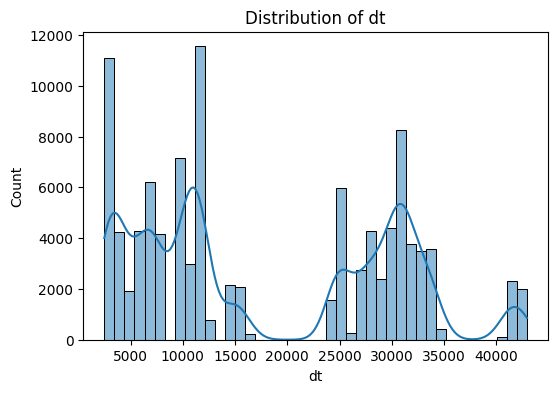

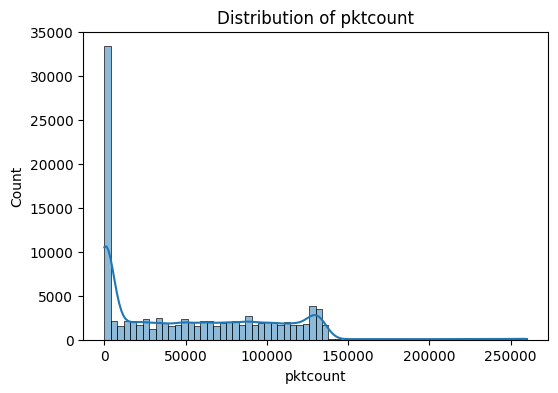

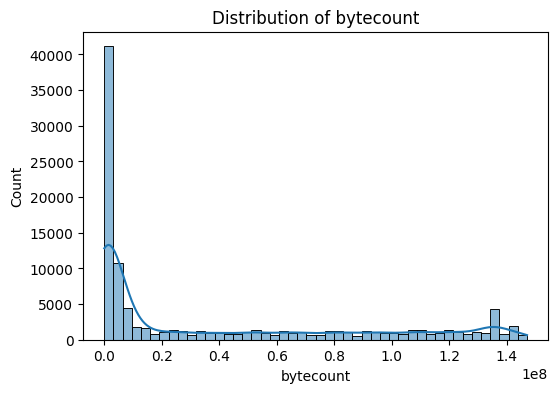

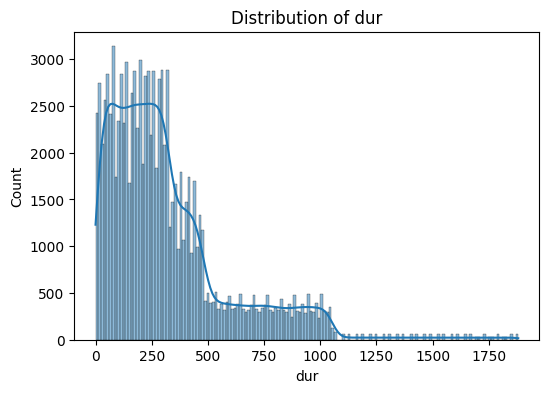

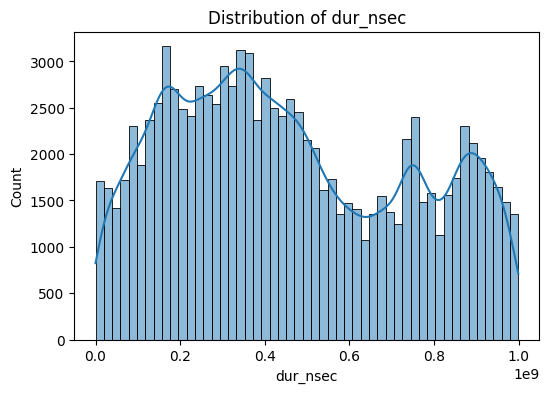

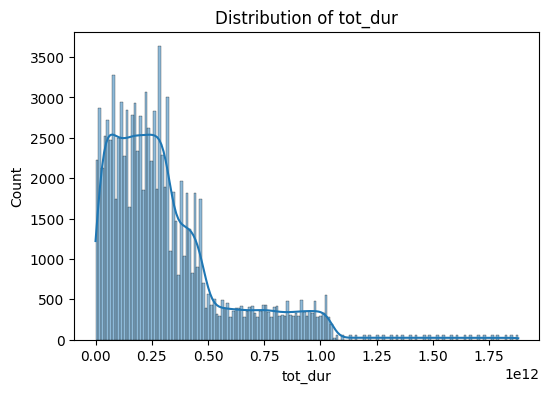

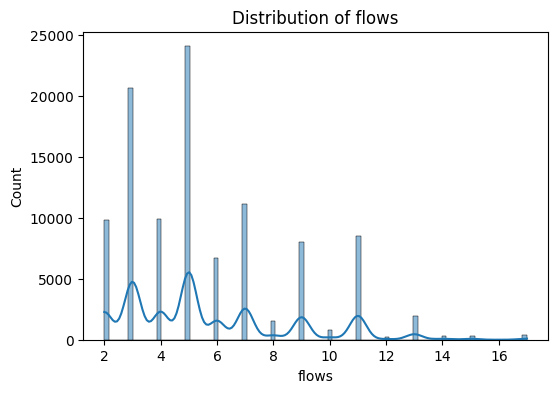

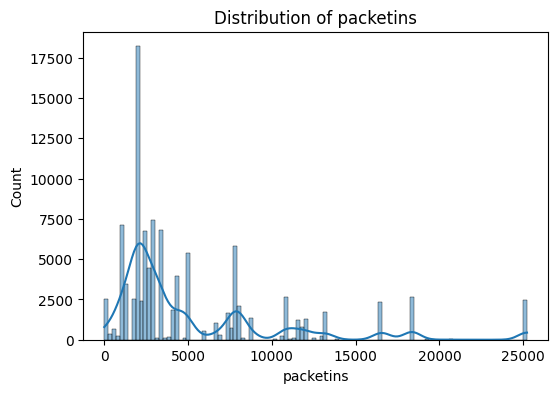

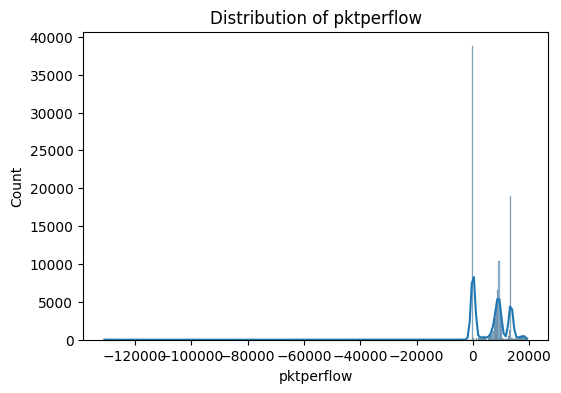

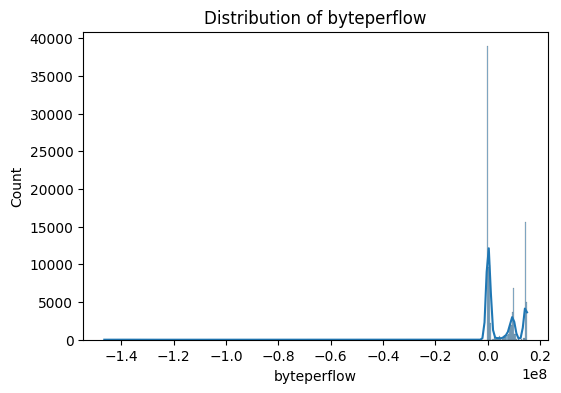

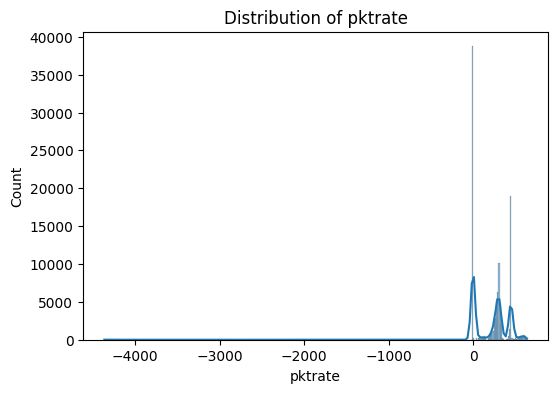

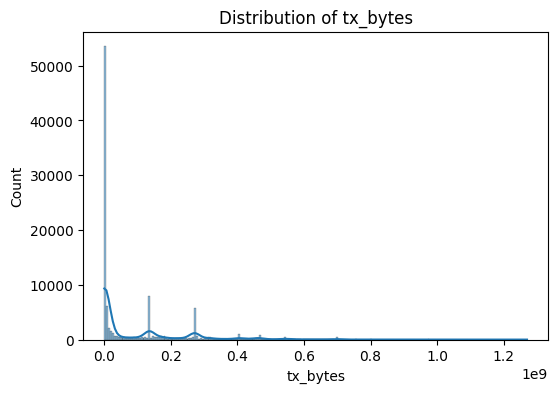

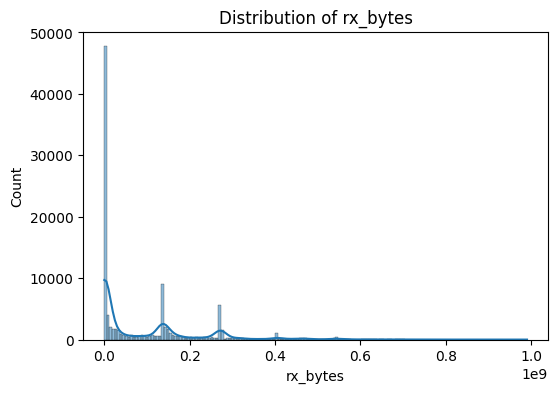

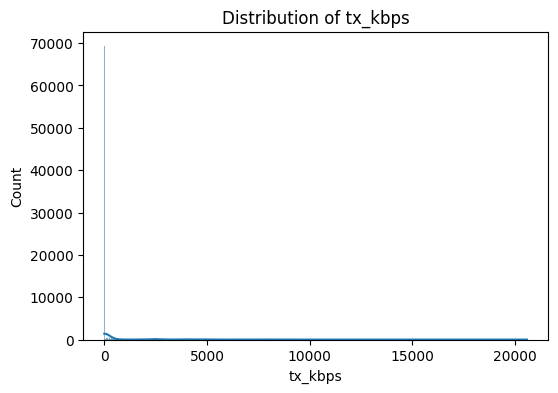

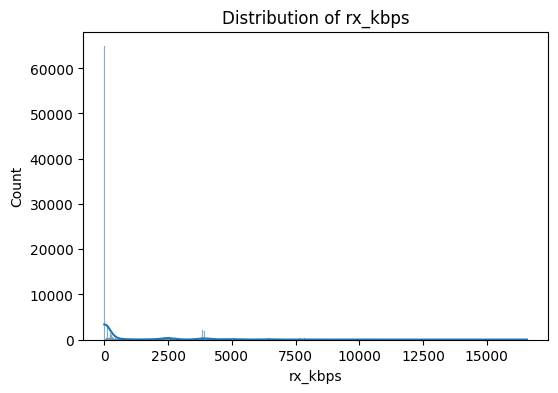

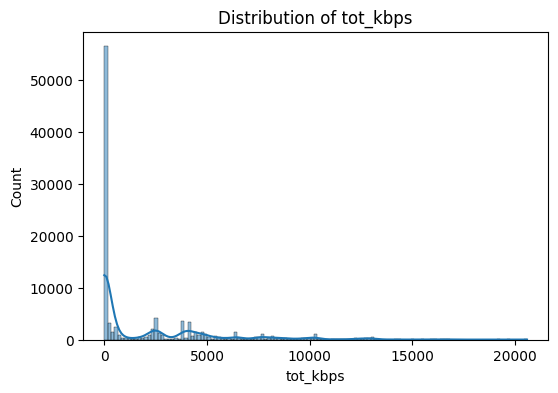

In [ ]:
numerical_features = ddos_data.select_dtypes(include=['int64', 'float64']).drop(columns=['switch', 'Pairflow', 'port_no', 'label']).columns
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(ddos_data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

There is an acceptable ratio of normal and ddos data

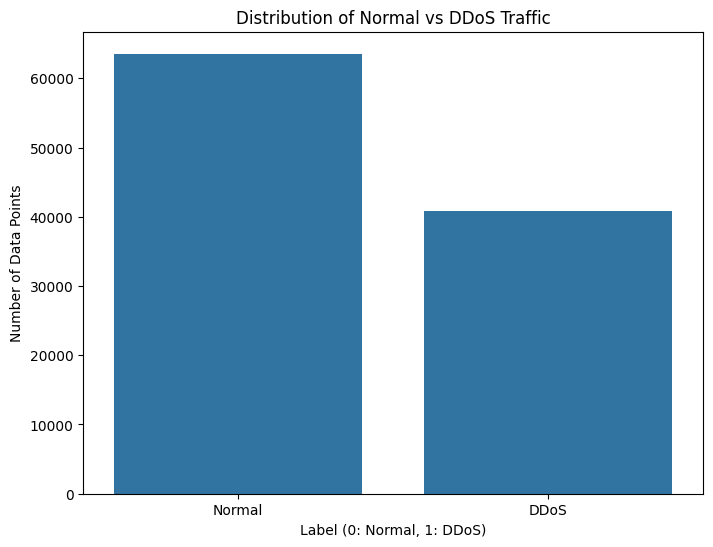

In [ ]:
label_counts = ddos_data['label'].value_counts()


plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribution of Normal vs DDoS Traffic')
plt.xlabel('Label (0: Normal, 1: DDoS)')
plt.ylabel('Number of Data Points')
plt.xticks(ticks=[0, 1], labels=['Normal', 'DDoS'])
plt.show()

Looking at the correlation, there are 4 pairs that have a correlation greater than 0.8. 'tot_dur' and 'dur' seem to be copies of each other so I will delete 'tot_dur'.

Then 'byteperflow', 'pktperflow', and 'pktrate' are related. Which makes sense. Because we have bytes, packets, and flows, I am just going to keep pktrate.

In [ ]:
correlation_matrix = ddos_data[numerical_features].corr()
print("Features with correlation greater than 0.8:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            print(f"Feature Pair: ({correlation_matrix.columns[i]}, {correlation_matrix.columns[j]}) => Correlation: {correlation_matrix.iloc[i, j]:.2f}")


Features with correlation greater than 0.8:
Feature Pair: (tot_dur, dur) => Correlation: 1.00
Feature Pair: (byteperflow, pktperflow) => Correlation: 0.81
Feature Pair: (pktrate, pktperflow) => Correlation: 1.00
Feature Pair: (pktrate, byteperflow) => Correlation: 0.81


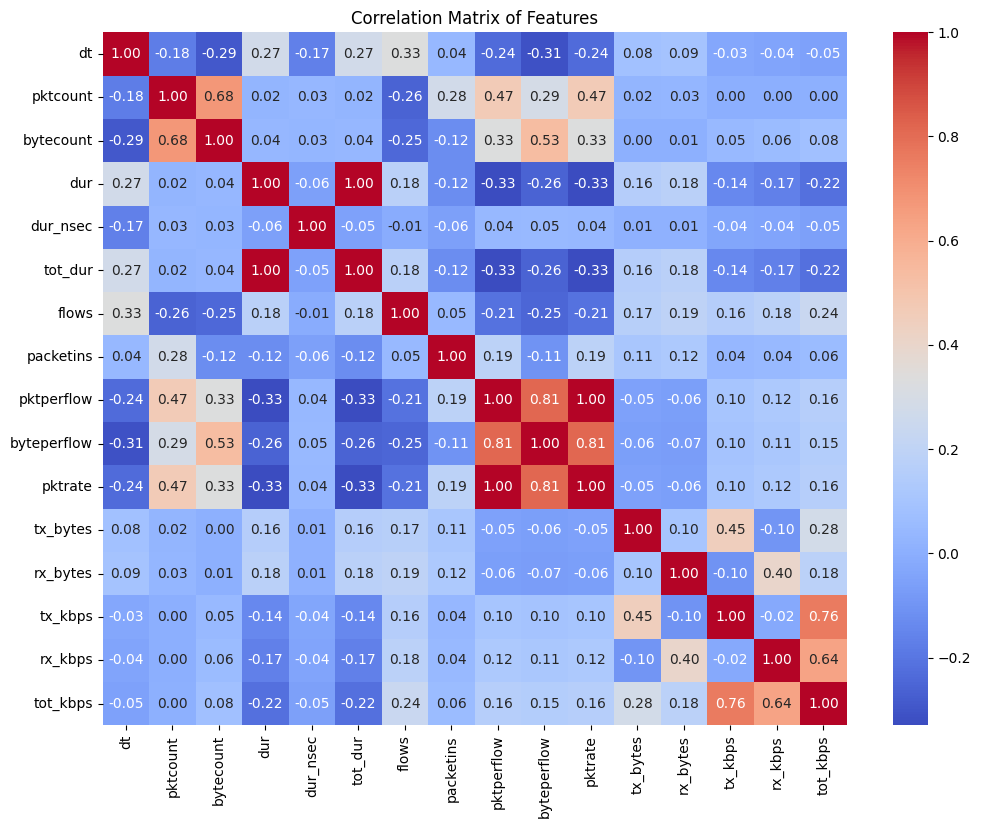

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [ ]:
correlation_with_label = ddos_data_encoded.corr()['label'].sort_values(ascending=False)
print("Correlation of features with 'label':")
print(correlation_with_label)

Correlation of features with 'label':
label                1.000000
pktcount             0.477796
bytecount            0.456360
pktrate              0.314075
bytes_per_packet     0.247958
Protocol_UDP         0.183749
packetins            0.110500
Protocol_TCP         0.103032
tot_kbps             0.083780
rx_kbps              0.061118
tx_kbps              0.051933
tx_rx_ratio_bytes    0.033108
dur_nsec             0.006142
rx_bytes            -0.075338
tx_bytes            -0.084780
dur                 -0.107476
dt                  -0.116176
flows               -0.196139
Protocol_ICMP       -0.270341
Name: label, dtype: float64


From the correlation analysis, we can see that `pktcount`, `pktrate`, and `bytes_per_packet` are among the most positively correlated features with the 'label' (DDoS attack). This means as these values increase, the likelihood of a DDoS attack also increases. Conversely, features like `Protocol_ICMP` and `flows` show negative correlations, suggesting they are less common in DDoS attacks or more prevalent in normal traffic.

# Data Cleaning

Deleting these three features based on the EDA

In [ ]:
ddos_data_clean = ddos_data.copy()
ddos_data_clean.drop(columns=['byteperflow', 'pktperflow', 'tot_dur'], inplace=True)
ddos_data_clean.head()

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,flows,packetins,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,3,1943,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2,1943,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,3,1943,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,3,1943,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,3,1943,451,0,UDP,3,3413,3665,0,0.0,0.0,0


I am adding the median value to rx_kbps, but I'm adding the median rx to the tx to get the total to keep tot = tx + rx as true

In [ ]:
median_val = ddos_data_clean['rx_kbps'].median()
ddos_data_clean.fillna({'rx_kbps': median_val}, inplace=True)

tot_index = ddos_data_clean[ddos_data_clean['tot_kbps'].isnull()].index
ddos_data_clean.loc[tot_index, 'tot_kbps'] = ddos_data_clean.loc[tot_index, 'tx_kbps'] + ddos_data_clean.loc[tot_index, 'rx_kbps']

ddos_data_clean.isnull().sum()

,0
dt,0
switch,0
src,0
dst,0
pktcount,0
bytecount,0
dur,0
dur_nsec,0
flows,0
packetins,0


# Feature Engineering

I am adding two new features based on what I know about the data. First is bytes per packet, which is important to distinguish network data where a lot of data is sent at once, like a download, vs an attack where a lot of data is sent in a lot of packets.

And second is the ratio of transmission bytes and receiving bytes, which is useful because it might not be an attack if the server is matching the high data.

In [ ]:
ddos_data_clean['bytes_per_packet'] = ddos_data_clean['bytecount'] / (ddos_data_clean['pktcount'] + 1e-6)

ddos_data_clean['tx_rx_ratio_bytes'] = ddos_data_clean['tx_bytes'] / (ddos_data_clean['rx_bytes'] + 1e-6)


I use logarithmic scaling to try to keep the feature of huge data spikes. Robust scaler scales to median = 0. This is to keep the features of an attack

In [ ]:
from sklearn.preprocessing import RobustScaler

ddos_data_clean['pktrate'] = ddos_data_clean['pktrate'].clip(lower=0)

numerical_features = ddos_data_clean.select_dtypes(include=['int64', 'float64']).drop(columns=['switch', 'Pairflow', 'port_no', 'label']).columns

for col in numerical_features:
  ddos_data_clean[col] = np.log1p(ddos_data_clean[col])

scaler = RobustScaler()
ddos_data_clean[numerical_features] = scaler.fit_transform(ddos_data_clean[numerical_features])
ddos_data_clean[numerical_features].describe()


,dt,pktcount,bytecount,dur,dur_nsec,flows,packetins,pktrate,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,bytes_per_packet,tx_rx_ratio_bytes
count,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000
mean,0.078185,-0.268578,-0.104216,-0.158596,-0.176599,0.017210,0.053168,-0.330822,-0.140026,-0.219450,0.450004,0.442580,0.270034,4.235333e-01,0.814829
std,0.581877,0.533504,0.492515,0.928648,0.959654,0.613093,0.840351,0.471134,0.470229,0.483200,0.616169,0.559272,0.474241,5.580558e-01,2.137325
min,-1.087163,-2.238803,-2.284671,-4.720290,-18.045769,-1.000000,-4.761509,-0.967799,-0.723142,-0.909841,0.000000,0.000000,-0.195013,-1.951437e+00,-0.504185
25%,-0.359170,-0.833213,-0.640767,-0.578273,-0.527401,-0.584963,-0.328695,-0.967799,-0.661797,-0.776189,0.000000,0.000000,-0.195013,-5.004106e-09,-0.451684
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
75%,0.640830,0.166787,0.359233,0.421727,0.472599,0.415037,0.671305,0.032201,0.338203,0.223811,1.000000,1.000000,0.804987,1.000000e+00,0.548316
max,0.890943,0.378591,0.455074,1.716435,0.792041,1.584963,1.576650,0.144111,0.556192,0.405570,1.796229,1.548864,1.008448,1.079522e+00,8.074342


Finaly I used one hot encoding on the catagorical features

In [ ]:
# Original cat_features were: ['src', 'dst', 'Protocol', 'switch', 'Pairflow', 'port_no']
features_to_encode = ['Protocol']
features_to_drop_entirely = ['src', 'dst', 'switch', 'Pairflow', 'port_no']

# Drop features that are not to be encoded nor kept
ddos_data_temp = ddos_data_clean.drop(columns=features_to_drop_entirely, errors='ignore')

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Add handle_unknown and sparse_output for robustness

encoded_data = pd.DataFrame(
    ohe.fit_transform(ddos_data_temp[features_to_encode]), # Removed .toarray()
    columns=ohe.get_feature_names_out(features_to_encode)
)

# Now, drop the original 'Protocol' column from ddos_data_temp before concatenating encoded_data
ddos_data_encoded = pd.concat([ddos_data_temp.drop(columns=features_to_encode), encoded_data], axis=1)

ddos_data_encoded.head()

,dt,pktcount,bytecount,dur,dur_nsec,flows,packetins,pktrate,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label,bytes_per_packet,tx_rx_ratio_bytes,Protocol_ICMP,Protocol_TCP,Protocol_UDP
0,-0.028584,0.011798,0.292789,-0.780515,0.489256,-0.584963,-0.328695,0.084263,0.343984,-0.766629,0.0,0.0,-0.195013,0,1.009661,6.758410,0.0,0.0,1.0
1,-0.017726,0.227178,0.442258,0.092986,0.511827,-1.000000,-0.328695,0.084263,-0.682324,-0.776696,0.0,0.0,-0.195013,0,1.009661,0.005606,0.0,0.0,1.0
2,-0.028584,0.156664,0.393323,-0.193035,0.524128,-0.584963,-0.328695,0.084263,-0.683523,-0.874804,0.0,0.0,-0.195013,0,1.009661,0.463133,0.0,0.0,1.0
3,-0.028584,0.156664,0.393323,-0.193035,0.524128,-0.584963,-0.328695,0.084263,-0.686310,-0.857536,0.0,0.0,-0.195013,0,1.009661,0.355766,0.0,0.0,1.0
4,-0.028584,0.156664,0.393323,-0.193035,0.524128,-0.584963,-0.328695,0.084263,-0.693860,-0.772893,0.0,0.0,-0.195013,0,1.009661,-0.049464,0.0,0.0,1.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Imports for CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def train_model(X, y, train_size=0.8, val_size=0.1, test_size=0.1, random_state=42):

    # First split: 80% train, 20% temporary for validation and test
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(val_size + test_size), random_state=random_state)

    # Second split: From the 20% temporary, split into 10% validation and 10% test
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=test_size / (val_size + test_size), random_state=random_state)

    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print("CNN Model Summary:")
    model.summary()

    print("\nTraining CNN model...")
    history = model.fit(X_train, y_train, epochs=10, batch_size=32,
                        validation_data=(X_val, y_val), verbose=1)
    print("CNN model training complete.")

    return model, X_test, y_test


In [ ]:
#important functions for the training

#this function evaluates the model and prints a confusion matrix and a classification report
def evaluate_model(model, X_test_reshaped, y_test):
  y_pred_prob = model.predict(X_test_reshaped)
  y_pred = (y_pred_prob > 0.5).astype(int) # Convert probabilities to binary predictions

  conf_matrix = confusion_matrix(y_test, y_pred)
  print("Confusion Matrix:")
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Predicted Normal', 'Predicted DDoS'],
              yticklabels=['Actual Normal', 'Actual DDoS'])
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))
  print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")


In [ ]:
#this funtion plots the ROC curves of a set of models
def plot_roc_curves(models_data):
  plt.figure(figsize=(10, 8))
  for name, model, X_test, y_test in models_data:
    # For CNN model, X_test needs to be reshaped before prediction
    y_prob = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

  plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.legend(loc='lower right')
  plt.grid(True)
  plt.show()

#this function creates a bar graph of the models accuracy
def plot_accuracy_scores(models_data):
    accuracy_scores = []
    model_names = []
    for name, model, X_test, y_test in models_data:
        if isinstance(model, tf.keras.Model):
            # For Keras models, evaluate returns (loss, accuracy)
            _, score = model.evaluate(X_test, y_test, verbose=0)
        else:
            score = model.score(X_test, y_test)
        accuracy_scores.append(score)
        model_names.append(name)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=model_names, y=accuracy_scores)
    plt.ylim(min(accuracy_scores) * 0.9, max(accuracy_scores) * 1.05)
    plt.title('Accuracy Scores of Different Models')
    plt.ylabel('Accuracy Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:

X_default = ddos_data_encoded.drop('label', axis=1)
y_default = ddos_data_encoded['label']
model, X_test, y_test = train_model(X_default, y_default)

CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN model...
Epoch 1/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8125 - loss: 0.3512 - val_accuracy: 0.9513 - val_loss: 0.1123
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9492 - loss: 0.1189 - val_accuracy: 0.9581 - val_loss: 0.0938
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9574 - loss: 0.0987 - val_accuracy: 0.9696 - val_loss: 0.0739
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9654 - loss: 0.0834 - val_accuracy: 0.9778 - val_loss: 0.0568
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9716 - loss: 0.0697 - val_accuracy: 0.9818 - val_loss: 0.0483
Epoch 6/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9762 - loss: 0.0602 - val_accuracy: 0.9839 - val_loss: 0.0463
Epoch 7/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9799 - loss: 0.0530 - val_accuracy: 0.9888 - val_loss: 0.0357
Epoch 8/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 

In [ ]:
X_pkt = ddos_data_encoded[['pktcount', 'bytes_per_packet']]
y_pkt = ddos_data_encoded['label']
model_pkt, X_test_pkt, y_test_pkt = train_model(X_pkt, y_pkt)


CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN model...
Epoch 1/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6833 - loss: 0.5161 - val_accuracy: 0.7211 - val_loss: 0.4820
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7127 - loss: 0.4844 - val_accuracy: 0.7248 - val_loss: 0.4736
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7141 - loss: 0.4773 - val_accuracy: 0.7253 - val_loss: 0.4694
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7161 - loss: 0.4764 - val_accuracy: 0.7233 - val_loss: 0.4723
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7178 - loss: 0.4754 - val_accuracy: 0.7212 - val_loss: 0.4701
Epoch 6/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7139 - loss: 0.4752 - val_accuracy: 0.7254 - val_loss: 0.4691
Epoch 7/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7153 - loss: 0.4754 - val_accuracy: 0.7236 - val_loss: 0.4707
Epoch 8/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 

In [ ]:
X_five = ddos_data_encoded[['pktcount', 'bytes_per_packet', 'bytecount', 'pktrate', 'Protocol_UDP']]
y_five = ddos_data_encoded['label']
model_five, X_test_five, y_test_five = train_model(X_five, y_five)

CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN model...
Epoch 1/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8231 - loss: 0.3472 - val_accuracy: 0.9279 - val_loss: 0.1640
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9285 - loss: 0.1633 - val_accuracy: 0.9372 - val_loss: 0.1419
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9339 - loss: 0.1468 - val_accuracy: 0.9410 - val_loss: 0.1343
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9365 - loss: 0.1367 - val_accuracy: 0.9372 - val_loss: 0.1284
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9353 - loss: 0.1346 - val_accuracy: 0.9388 - val_loss: 0.1258
Epoch 6/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9356 - loss: 0.1325 - val_accuracy: 0.9421 - val_loss: 0.1218
Epoch 7/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9355 - loss: 0.1291 - val_accuracy: 0.9440 - val_loss: 0.1213
Epoch 8/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix:


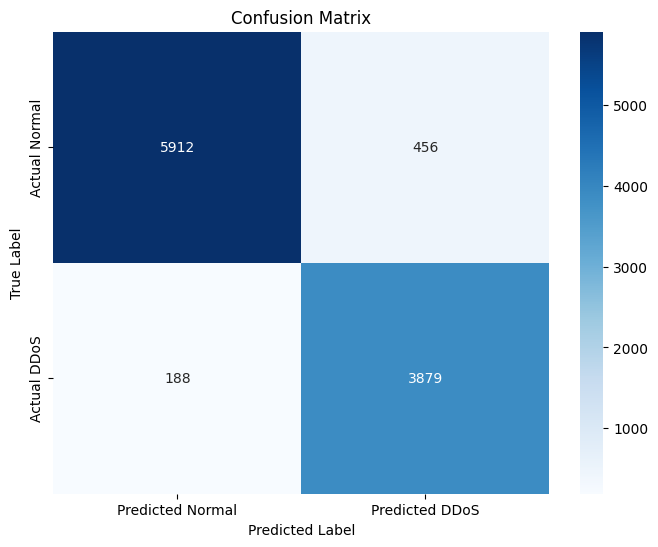


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      6368
           1       0.89      0.95      0.92      4067

    accuracy                           0.94     10435
   macro avg       0.93      0.94      0.94     10435
weighted avg       0.94      0.94      0.94     10435

Accuracy Score: 0.9383


In [ ]:
evaluate_model(model_five, X_test_five, y_test_five)

327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion Matrix:


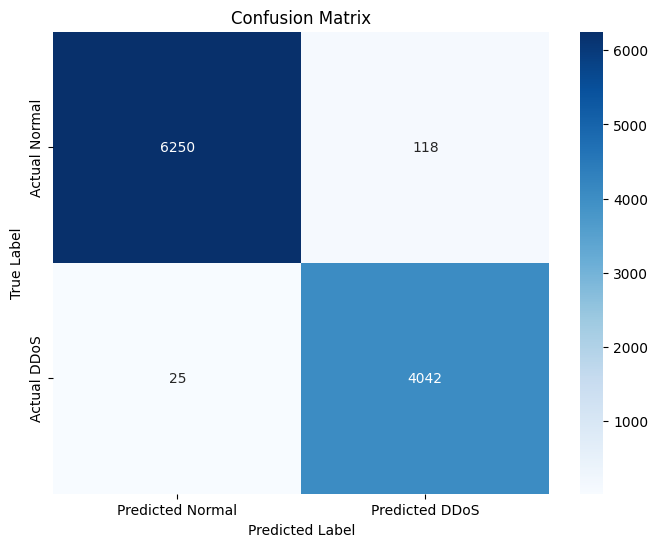


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6368
           1       0.97      0.99      0.98      4067

    accuracy                           0.99     10435
   macro avg       0.98      0.99      0.99     10435
weighted avg       0.99      0.99      0.99     10435

Accuracy Score: 0.9863


In [ ]:
evaluate_model(model, X_test, y_test)

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Confusion Matrix:


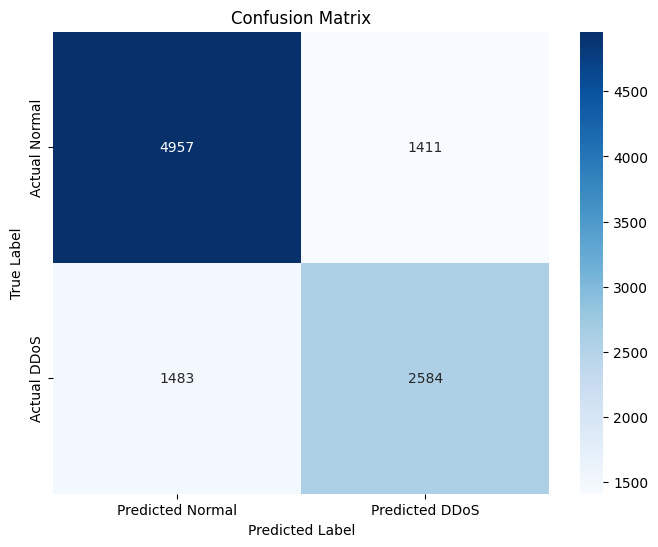


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.77      6368
           1       0.65      0.64      0.64      4067

    accuracy                           0.72     10435
   macro avg       0.71      0.71      0.71     10435
weighted avg       0.72      0.72      0.72     10435

Accuracy Score: 0.7227


In [ ]:
evaluate_model(model_pkt, X_test_pkt, y_test_pkt)

In [ ]:
X_small = ddos_data_encoded[['pktcount', 'bytes_per_packet']]
y_small = ddos_data_encoded['label']
model_small, X_test_small, y_test_small = train_model(X_small, y_small)

CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN model...
Epoch 1/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6969 - loss: 0.4990 - val_accuracy: 0.7495 - val_loss: 0.4364
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7422 - loss: 0.4408 - val_accuracy: 0.7564 - val_loss: 0.4273
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7475 - loss: 0.4335 - val_accuracy: 0.7585 - val_loss: 0.4230
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7519 - loss: 0.4300 - val_accuracy: 0.7695 - val_loss: 0.4193
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7547 - loss: 0.4256 - val_accuracy: 0.7673 - val_loss: 0.4152
Epoch 6/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7615 - loss: 0.4212 - val_accuracy: 0.7646 - val_loss: 0.4238
Epoch 7/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7643 - loss: 0.4214 - val_accuracy: 0.7779 - val_loss: 0.4032
Epoch 8/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix:


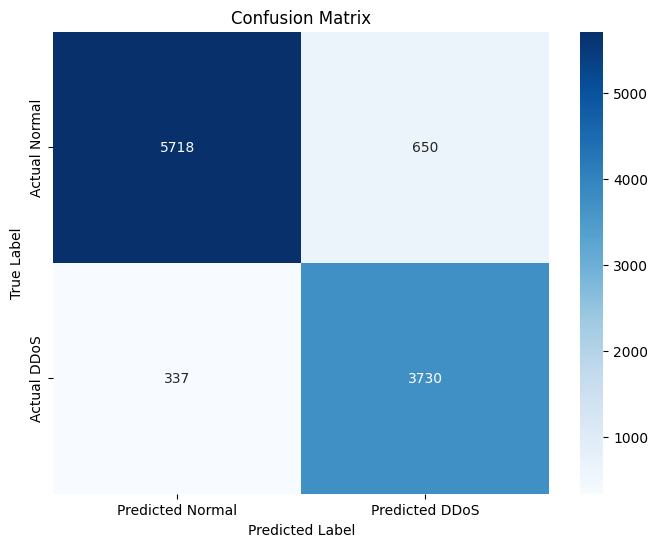


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      6368
           1       0.85      0.92      0.88      4067

    accuracy                           0.91     10435
   macro avg       0.90      0.91      0.90     10435
weighted avg       0.91      0.91      0.91     10435

Accuracy Score: 0.9054


In [ ]:
evaluate_model(model_small, X_test_small, y_test_small)

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


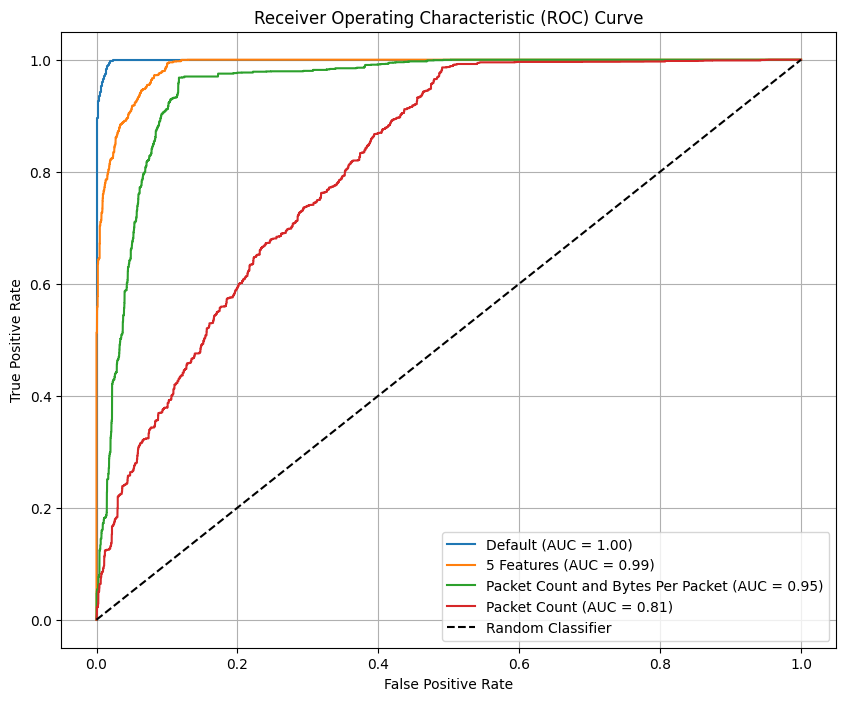

In [ ]:
modelsdata = [
    ('Default', model, X_test, y_test),
    ('5 Features', model_five, X_test_five, y_test_five),
    ('Packet Count and Bytes Per Packet', model_small, X_test_small, y_test_small),
    ('Packet Count', model_pkt, X_test_pkt, y_test_pkt)
]
plot_roc_curves(modelsdata)